# 07 – Modelling: Árbol de Decisión y Random Forest

**Proyecto:** Predicción de subempleo por insuficiencia de horas – EPEN 2024  
**Target:** `target_subempleo_horas` (1 = Subempleado por horas, 0 = No subempleado por horas)

Los modelos basados en árboles pueden capturar interacciones no lineales entre variables laborales, ingresos, horas, educación y protección social. No requieren escalamiento estricto de variables.

> Los modelos se entrenan **únicamente** con `X_train_selected` / `y_train_selected`.  
> La evaluación se realiza sobre `X_test_selected` / `y_test_selected`.

In [1]:
%pip install pandas matplotlib seaborn scikit-learn numpy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import joblib

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

pd.set_option("display.max_columns", 50)
print("Librerías importadas.")

Librerías importadas.


## 1. Carga de Archivos

In [3]:
SELECTED_DIR = Path("../data/selected")
RESULTS_DIR  = Path("../data/results")
MODELS_DIR   = Path("../models")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

required = {
    "X_train": SELECTED_DIR / "X_train_selected.csv",
    "X_test":  SELECTED_DIR / "X_test_selected.csv",
    "y_train": SELECTED_DIR / "y_train_selected.csv",
    "y_test":  SELECTED_DIR / "y_test_selected.csv",
}
for name, path in required.items():
    if not path.exists():
        raise FileNotFoundError(
            f"Archivo no encontrado: {path}\n"
            "Primero debe ejecutarse 06_feature_selection/selected_variables.ipynb"
        )

X_train = pd.read_csv(required["X_train"])
X_test  = pd.read_csv(required["X_test"])

TARGET_COL = "target_subempleo_horas"

def load_target(path, name):
    df = pd.read_csv(path)
    if TARGET_COL not in df.columns:
        raise ValueError(
            f"No se encontró '{TARGET_COL}' en {name}. "
            f"Se esperaba un artefacto real con esa columna exacta en {path.name}."
        )
    return df[TARGET_COL].reset_index(drop=True)

y_train = load_target(required["y_train"], "y_train")
y_test  = load_target(required["y_test"],  "y_test")

print("Dimensiones:")
print(f"  X_train : {X_train.shape}")
print(f"  X_test  : {X_test.shape}")
print(f"  y_train : {y_train.shape}  | clase 1: {y_train.mean():.2%}")
print(f"  y_test  : {y_test.shape}   | clase 1: {y_test.mean():.2%}")

Dimensiones:
  X_train : (19243, 33)
  X_test  : (4811, 33)
  y_train : (19243,)  | clase 1: 24.90%
  y_test  : (4811,)   | clase 1: 24.90%


In [4]:
# 2. Validaciones
assert list(X_train.columns) == list(X_test.columns), \
    "X_train y X_test no coinciden en columnas."
assert X_train.isnull().sum().sum() == 0, "X_train tiene nulos."
assert X_test.isnull().sum().sum() == 0,  "X_test tiene nulos."
assert set(y_train.unique()).issubset({0, 1}), \
    f"y_train tiene valores inesperados: {y_train.unique()}"

LEAKAGE = ["P209H", "C333", "C334", TARGET_COL]
for v in LEAKAGE:
    assert v not in X_train.columns, f"Leakage en X_train: '{v}'"
    assert v not in X_test.columns,  f"Leakage en X_test: '{v}'"

print("Todas las validaciones pasaron correctamente.")
print(f"Distribución y_train: {dict(y_train.value_counts().sort_index())}")
print(f"Distribución y_test : {dict(y_test.value_counts().sort_index())}")

Todas las validaciones pasaron correctamente.
Distribución y_train: {0: np.int64(14451), 1: np.int64(4792)}
Distribución y_test : {0: np.int64(3613), 1: np.int64(1198)}


In [ ]:
def _get_estimator_info(model):
    if hasattr(model, "best_estimator_"):
        m = model.best_estimator_
    elif hasattr(model, "named_steps"):
        m = list(model.named_steps.values())[-1]
    else:
        m = model
    return type(m).__name__, getattr(m, "class_weight", None)


def evaluate_model(name, model, X_tr, X_te, y_tr, y_te, refit=True, show_cm=True):
    if refit:
        model.fit(X_tr, y_tr)

    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1] if hasattr(model, "predict_proba") else None

    acc = float(accuracy_score(y_te, y_pred))
    p0  = float(precision_score(y_te, y_pred, pos_label=0, zero_division=0))
    r0  = float(recall_score(y_te, y_pred,    pos_label=0, zero_division=0))
    f0  = float(f1_score(y_te, y_pred,        pos_label=0, zero_division=0))
    p1  = float(precision_score(y_te, y_pred, pos_label=1, zero_division=0))
    r1  = float(recall_score(y_te, y_pred,    pos_label=1, zero_division=0))
    f1  = float(f1_score(y_te, y_pred,        pos_label=1, zero_division=0))
    auc = float(roc_auc_score(y_te, y_prob)) if y_prob is not None else float(np.nan)

    mtype, cw = _get_estimator_info(model)

    print(f"\n{'='*60}\nModelo: {name}\n{'='*60}")
    print(
        classification_report(
            y_te,
            y_pred,
            target_names=["No subempleado por horas", "Subempleado por horas"],
        )
    )
    print(f"ROC-AUC: {auc:.4f}" if not np.isnan(auc) else "ROC-AUC: N/A")

    if show_cm:
        cm = confusion_matrix(y_te, y_pred)
        _, ax = plt.subplots(figsize=(5, 4))
        ConfusionMatrixDisplay(
            cm,
            display_labels=["No subempleado por horas", "Subempleado por horas"],
        ).plot(
            ax=ax, colorbar=False
        )
        ax.set_title(f"Confusión – {name}")
        plt.tight_layout()
        plt.show()

    return {
        "model_name":        name,
        "model_type":        mtype,
        "uses_class_weight": str(cw),
        "accuracy":          round(acc, 4),
        "precision_0":       round(p0, 4),
        "recall_0":          round(r0, 4),
        "f1_0":              round(f0, 4),
        "precision_1":       round(p1, 4),
        "recall_1":          round(r1, 4),
        "f1_1":              round(f1, 4),
        "roc_auc":           round(auc, 4) if not np.isnan(auc) else np.nan,
    }

print("Funciones definidas.")

Funciones definidas.


## 2. Modelos Basados en Árboles


Modelo: Decision Tree (base)
                          precision    recall  f1-score   support

No subempleado por horas       0.78      0.78      0.78      3613
   Subempleado por horas       0.34      0.35      0.35      1198

                accuracy                           0.67      4811
               macro avg       0.56      0.56      0.56      4811
            weighted avg       0.67      0.67      0.67      4811

ROC-AUC: 0.5642


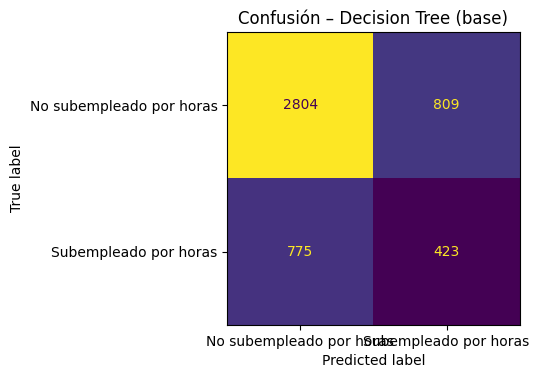


Modelo: Decision Tree (balanced)
                          precision    recall  f1-score   support

No subempleado por horas       0.79      0.78      0.78      3613
   Subempleado por horas       0.35      0.35      0.35      1198

                accuracy                           0.68      4811
               macro avg       0.57      0.57      0.57      4811
            weighted avg       0.68      0.68      0.68      4811

ROC-AUC: 0.5686


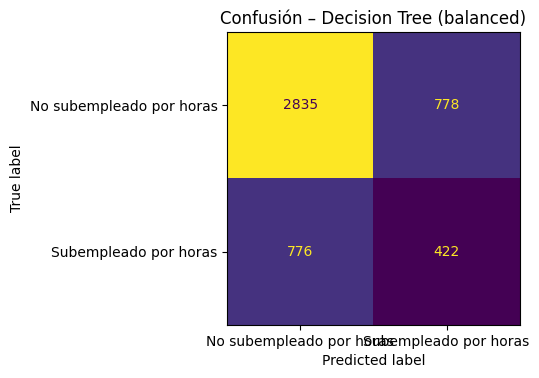

['..\\models\\decision_tree_balanced.pkl']

In [6]:
all_metrics_trees = []

# ── 2.1 Decision Tree Base ────────────────────────────────────────────────
dt_base = DecisionTreeClassifier(random_state=42)
m = evaluate_model("Decision Tree (base)", dt_base, X_train, X_test, y_train, y_test)
all_metrics_trees.append(m)
joblib.dump(dt_base, MODELS_DIR / "decision_tree_base.pkl")

# ── 2.2 Decision Tree Balanceado ─────────────────────────────────────────
dt_bal = DecisionTreeClassifier(random_state=42, class_weight="balanced")
m = evaluate_model("Decision Tree (balanced)", dt_bal, X_train, X_test, y_train, y_test)
all_metrics_trees.append(m)
joblib.dump(dt_bal, MODELS_DIR / "decision_tree_balanced.pkl")

Mejores parámetros DT: {'class_weight': 'balanced', 'max_depth': 7, 'min_samples_leaf': 50, 'min_samples_split': 2}

Modelo: Decision Tree (GridSearchCV)
                          precision    recall  f1-score   support

No subempleado por horas       0.83      0.75      0.79      3613
   Subempleado por horas       0.41      0.52      0.46      1198

                accuracy                           0.70      4811
               macro avg       0.62      0.64      0.62      4811
            weighted avg       0.72      0.70      0.71      4811

ROC-AUC: 0.6860


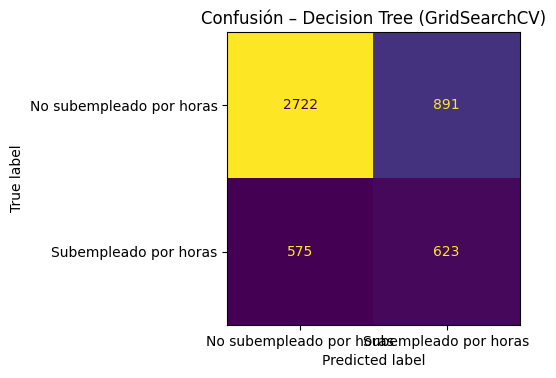

['..\\models\\decision_tree_optimized.pkl']

In [7]:
# ── 2.3 Decision Tree – GridSearchCV ─────────────────────────────────────
param_grid_dt = {
    "max_depth":         [3, 5, 7, 10, None],
    "min_samples_leaf":  [5, 10, 20, 50],
    "min_samples_split": [2, 10, 30],
    "class_weight":      [None, "balanced"],
}

gs_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=0,
)
gs_dt.fit(X_train, y_train)
print("Mejores parámetros DT:", gs_dt.best_params_)

m = evaluate_model(
    "Decision Tree (GridSearchCV)",
    gs_dt.best_estimator_,
    X_train, X_test, y_train, y_test,
    refit=False,
)
all_metrics_trees.append(m)
joblib.dump(gs_dt.best_estimator_, MODELS_DIR / "decision_tree_optimized.pkl")


Modelo: Random Forest (base)
                          precision    recall  f1-score   support

No subempleado por horas       0.79      0.95      0.86      3613
   Subempleado por horas       0.59      0.22      0.32      1198

                accuracy                           0.77      4811
               macro avg       0.69      0.59      0.59      4811
            weighted avg       0.74      0.77      0.73      4811

ROC-AUC: 0.6554


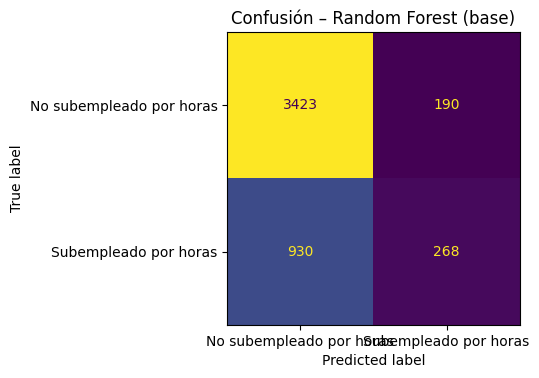


Modelo: Random Forest (balanced)
                          precision    recall  f1-score   support

No subempleado por horas       0.78      0.95      0.86      3613
   Subempleado por horas       0.58      0.20      0.30      1198

                accuracy                           0.76      4811
               macro avg       0.68      0.58      0.58      4811
            weighted avg       0.73      0.76      0.72      4811

ROC-AUC: 0.6529


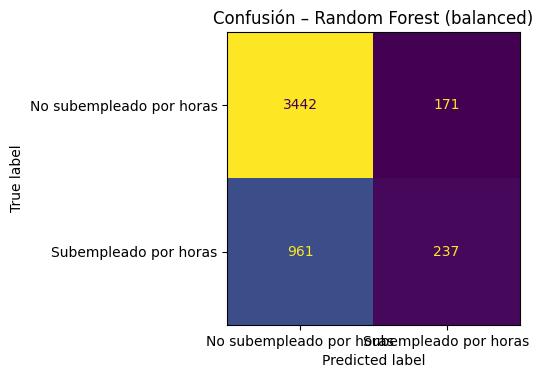

['..\\models\\random_forest_balanced.pkl']

In [8]:
# ── 2.4 Random Forest Base ────────────────────────────────────────────────
rf_base = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
m = evaluate_model("Random Forest (base)", rf_base, X_train, X_test, y_train, y_test)
all_metrics_trees.append(m)
joblib.dump(rf_base, MODELS_DIR / "random_forest_base.pkl")

# ── 2.5 Random Forest Balanceado ─────────────────────────────────────────
rf_bal = RandomForestClassifier(
    n_estimators=200, random_state=42, n_jobs=-1, class_weight="balanced"
)
m = evaluate_model("Random Forest (balanced)", rf_bal, X_train, X_test, y_train, y_test)
all_metrics_trees.append(m)
joblib.dump(rf_bal, MODELS_DIR / "random_forest_balanced.pkl")

Mejores parámetros RF: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_leaf': 10, 'min_samples_split': 2, 'n_estimators': 200}

Modelo: Random Forest (GridSearchCV)
                          precision    recall  f1-score   support

No subempleado por horas       0.82      0.81      0.81      3613
   Subempleado por horas       0.45      0.46      0.45      1198

                accuracy                           0.72      4811
               macro avg       0.63      0.64      0.63      4811
            weighted avg       0.73      0.72      0.72      4811

ROC-AUC: 0.6921


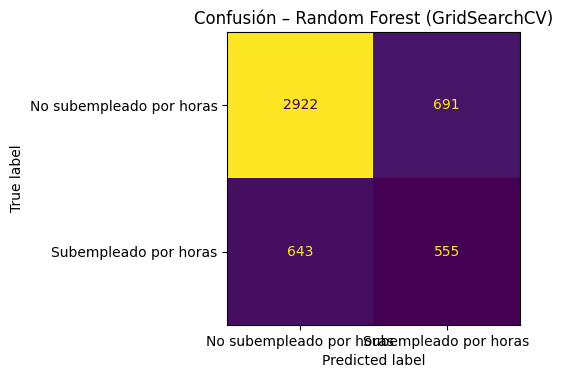

['..\\models\\random_forest_optimized.pkl']

In [9]:
# ── 2.6 Random Forest – GridSearchCV ─────────────────────────────────────
param_grid_rf = {
    "n_estimators":      [100, 200],
    "max_depth":         [5, 10, None],
    "min_samples_leaf":  [5, 10, 20],
    "min_samples_split": [2, 10],
    "class_weight":      [None, "balanced"],
}

gs_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid_rf,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=0,
)
gs_rf.fit(X_train, y_train)
print("Mejores parámetros RF:", gs_rf.best_params_)

m = evaluate_model(
    "Random Forest (GridSearchCV)",
    gs_rf.best_estimator_,
    X_train, X_test, y_train, y_test,
    refit=False,
)
all_metrics_trees.append(m)
joblib.dump(gs_rf.best_estimator_, MODELS_DIR / "random_forest_optimized.pkl")

## 3. Comparativas y Curvas ROC

Resumen de métricas – Modelos Árbol para subempleo por horas:
                  model_name  accuracy  precision_1  recall_1   f1_1  roc_auc
        Decision Tree (base)    0.6708       0.3433    0.3531 0.3481   0.5642
    Decision Tree (balanced)    0.6770       0.3517    0.3523 0.3520   0.5686
Decision Tree (GridSearchCV)    0.6953       0.4115    0.5200 0.4594   0.6860
        Random Forest (base)    0.7672       0.5852    0.2237 0.3237   0.6554
    Random Forest (balanced)    0.7647       0.5809    0.1978 0.2951   0.6529
Random Forest (GridSearchCV)    0.7227       0.4454    0.4633 0.4542   0.6921


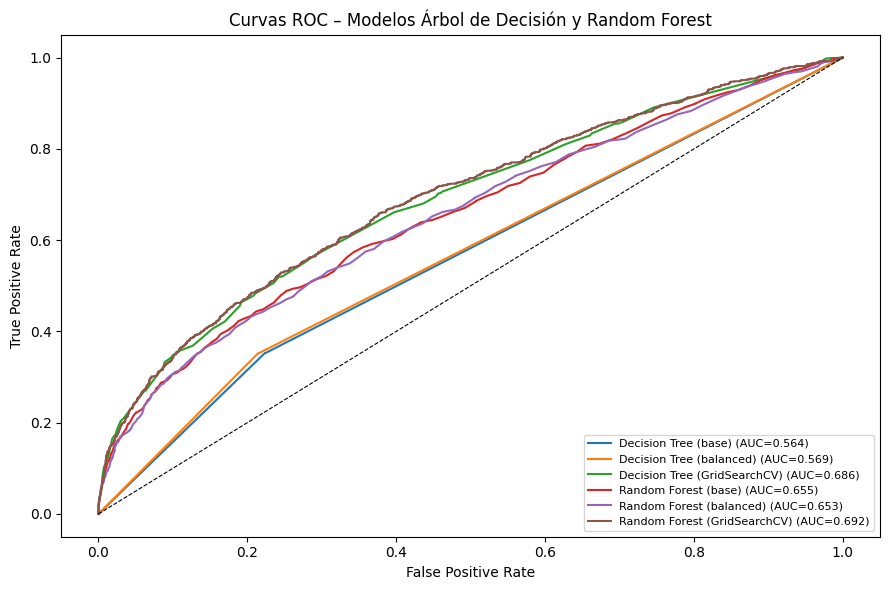

In [10]:
results_trees = pd.DataFrame(all_metrics_trees)

print("Resumen de métricas – Modelos Árbol para subempleo por horas:")
print(
    results_trees[["model_name", "accuracy", "precision_1", "recall_1", "f1_1", "roc_auc"]]
    .to_string(index=False)
)

# ── Curvas ROC comparativas ───────────────────────────────────────────────
tree_models = [
    ("Decision Tree (base)",         dt_base),
    ("Decision Tree (balanced)",     dt_bal),
    ("Decision Tree (GridSearchCV)", gs_dt.best_estimator_),
    ("Random Forest (base)",         rf_base),
    ("Random Forest (balanced)",     rf_bal),
    ("Random Forest (GridSearchCV)", gs_rf.best_estimator_),
]

fig, ax = plt.subplots(figsize=(9, 6))
for label, clf in tree_models:
    if hasattr(clf, "predict_proba"):
        fpr, tpr, _ = roc_curve(y_test, clf.predict_proba(X_test)[:, 1])
        auc_v = roc_auc_score(y_test, clf.predict_proba(X_test)[:, 1])
        ax.plot(fpr, tpr, label=f"{label} (AUC={auc_v:.3f})")

ax.plot([0, 1], [0, 1], "k--", linewidth=0.8)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Curvas ROC – Modelos Árbol de Decisión y Random Forest")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

## 4. Feature Importance – Random Forest Optimizado

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_34632\3096490932.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


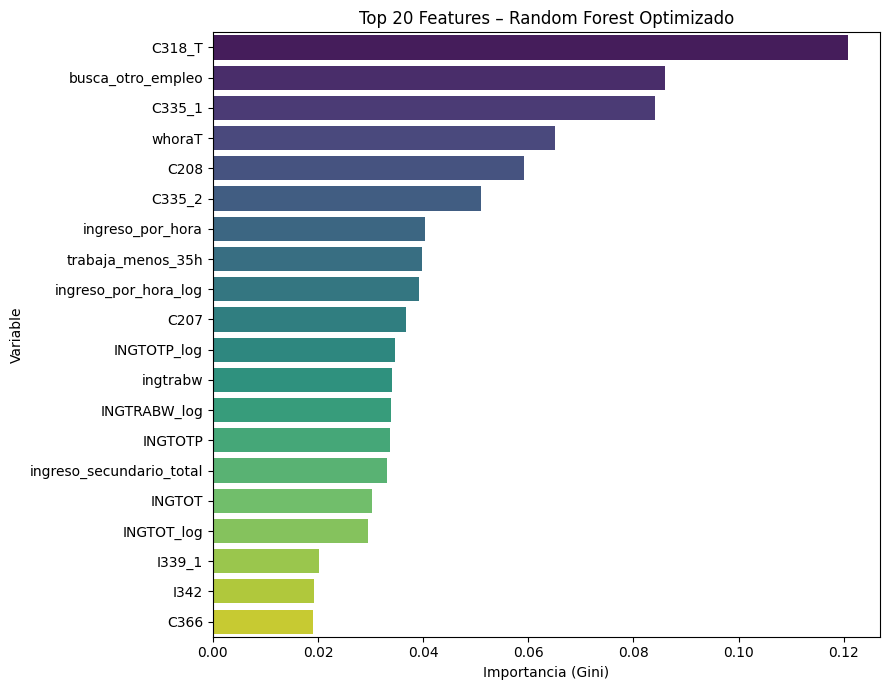

Feature importance guardada en: ..\data\results\tree_feature_importance.csv

Top 10 variables:
             feature  importance
              C318_T    0.120852
   busca_otro_empleo    0.086000
              C335_1    0.084084
              whoraT    0.065138
                C208    0.059274
              C335_2    0.050992
    ingreso_por_hora    0.040330
   trabaja_menos_35h    0.039740
ingreso_por_hora_log    0.039299
                C207    0.036692


In [ ]:
best_rf = gs_rf.best_estimator_
feat_imp = (
    pd.DataFrame({
        "feature":    X_train.columns,
        "importance": best_rf.feature_importances_,
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

TOP_N = 20
_, ax = plt.subplots(figsize=(9, 7))
sns.barplot(
    data=feat_imp.head(TOP_N),
    x="importance", y="feature",
    palette="viridis", ax=ax
)
ax.set_title(f"Top {TOP_N} Features – Random Forest Optimizado")
ax.set_xlabel("Importancia (Gini)")
ax.set_ylabel("Variable")
plt.tight_layout()
plt.show()

feat_imp.to_csv(RESULTS_DIR / "tree_feature_importance.csv", index=False)
print(f"Feature importance guardada en: {RESULTS_DIR / 'tree_feature_importance.csv'}")
print("\nTop 10 variables:")
print(feat_imp.head(10).to_string(index=False))

## 5. Guardar Resultados

In [12]:
results_trees.to_csv(RESULTS_DIR / "tree_models_metrics.csv", index=False)

model_files = [
    "decision_tree_base.pkl",
    "decision_tree_balanced.pkl",
    "decision_tree_optimized.pkl",
    "random_forest_base.pkl",
    "random_forest_balanced.pkl",
    "random_forest_optimized.pkl",
]

print(f"Métricas guardadas : {RESULTS_DIR / 'tree_models_metrics.csv'}")
print(f"\nModelos en        : {MODELS_DIR.resolve()}")
for fname in model_files:
    status = "OK" if (MODELS_DIR / fname).exists() else "NO ENCONTRADO"
    print(f"  [{status}] {fname}")

Métricas guardadas : ..\data\results\tree_models_metrics.csv

Modelos en        : C:\Users\ADMIN\Desktop\ML_PROYECTO_26_1\ml_project\models
  [OK] decision_tree_base.pkl
  [OK] decision_tree_balanced.pkl
  [OK] decision_tree_optimized.pkl
  [OK] random_forest_base.pkl
  [OK] random_forest_balanced.pkl
  [OK] random_forest_optimized.pkl


## 6. Conclusiones

- Los **Árboles de Decisión** sin restricción de profundidad tienden a sobreajustar; el GridSearchCV con `max_depth` y `min_samples_leaf` reduce este problema.
- El parámetro **`class_weight='balanced'`** aumenta el Recall de la clase positiva (`Subempleado por horas`), siendo especialmente útil cuando el desbalance de clases es relevante (~25 / 75).
- **Random Forest** generalmente supera al árbol individual en generalización, debido al efecto de ensemble y la diversidad entre árboles.
- La **Random Forest optimizada** se espera que sea la mejor candidata para `model_comparison.ipynb`, donde se comparará con los modelos base del notebook anterior.
- La **feature importance** permite identificar qué variables laborales, de ingresos o de horas trabajan son más relevantes para la predicción del subempleo por horas.